# **CASO 1: Reconocimiento de Rostros con Eigenfaces (PCA)**

---



### Análisis de Clustering Jerárquico sobre el Dataset 20 Newsgroups

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    homogeneity_score,
    v_measure_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Carga del dataset

In [ ]:
# Se seleccionan categorías con temas claramente distintos entre sí,
# para poder verificar si el clustering jerárquico logra "descubrirlas"
# sin conocer las etiquetas reales.
categories = [
    "comp.graphics",
    "rec.sport.baseball",
    "sci.space",
    "talk.politics.mideast",
    "soc.religion.christian",
]

data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),  # evita "trampas" como firmas
    shuffle=True,
    random_state=RANDOM_STATE,
)

X_text = data.data
y_true = data.target
target_names = data.target_names

print(f"Documentos cargados: {len(X_text)}")
print(f"Categorías: {target_names}")

Documentos cargados: 2937
Categorías: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'soc.religion.christian', 'talk.politics.mideast']


### Vectorización TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(max_df=0.5, min_df=5, stop_words="english")
X_tfidf = vectorizer.fit_transform(X_text)

print(f"Matriz TF-IDF: {X_tfidf.shape}")

Matriz TF-IDF: (2937, 7742)


### Reducción de dimensionalidad (LSA / SVD)

In [ ]:
# AgglomerativeClustering con linkage='ward' necesita una matriz densa y
# distancias euclidianas confiables. En miles de dimensiones todas las
# distancias tienden a "verse iguales" (maldición de la dimensionalidad),
# así que reducimos a 100 componentes principales latentes.
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_tfidf)

print(f"Varianza explicada acumulada: {svd.explained_variance_ratio_.sum():.2%}")

Varianza explicada acumulada: 18.37%


### Clustering jerárquico con distintos criterios de linkage

In [ ]:
n_clusters = len(categories)
linkages_to_test = ["ward", "complete", "single"]

results = {}
for link in linkages_to_test:
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=link)
    labels = model.fit_predict(X_reduced)

    sil = silhouette_score(X_reduced, labels)
    ari = adjusted_rand_score(y_true, labels)
    hom = homogeneity_score(y_true, labels)
    vms = v_measure_score(y_true, labels)

    results[link] = {
        "labels": labels,
        "silhouette": sil,
        "ari": ari,
        "homogeneity": hom,
        "v_measure": vms,
        "cluster_sizes": np.bincount(labels),
    }

    print(f"\n--- Linkage = {link} ---")
    print(f"  Silhouette Score:    {sil:.4f}")
    print(f"  Adjusted Rand Index: {ari:.4f}")
    print(f"  Homogeneity:         {hom:.4f}")
    print(f"  V-measure:           {vms:.4f}")
    print(f"  Tamaño de clusters:  {results[link]['cluster_sizes']}")


--- Linkage = ward ---
  Silhouette Score:    0.0643
  Adjusted Rand Index: 0.1637
  Homogeneity:         0.3309
  V-measure:           0.3935
  Tamaño de clusters:  [1917  328  108  218  366]

--- Linkage = complete ---
  Silhouette Score:    0.1600
  Adjusted Rand Index: 0.0112
  Homogeneity:         0.0526
  V-measure:           0.0889
  Tamaño de clusters:  [2707  217    5    6    2]

--- Linkage = single ---
  Silhouette Score:    0.2270
  Adjusted Rand Index: 0.0000
  Homogeneity:         0.0014
  V-measure:           0.0027
  Tamaño de clusters:  [2933    1    1    1    1]


### Selección del mejor criterio

In [ ]:
best_link = max(results, key=lambda k: results[k]["ari"])
print(f">>> Mejor criterio de linkage encontrado: '{best_link}' <<<")

>>> Mejor criterio de linkage encontrado: 'ward' <<<


### Dendrograma del mejor linkage

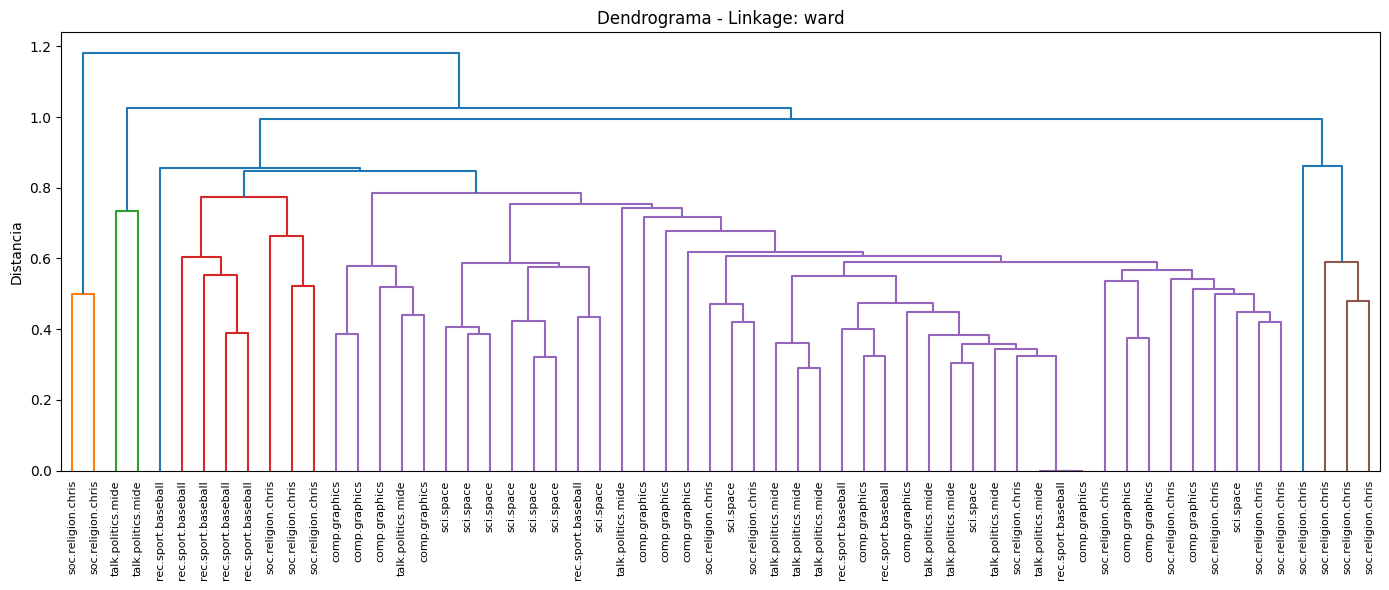

In [ ]:
sample_idx = np.random.choice(len(X_reduced), size=60, replace=False)
Z = linkage(X_reduced[sample_idx], method=best_link)

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=[target_names[y_true[i]][:18] for i in sample_idx],
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.title(f"Dendrograma - Linkage: {best_link}")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

### Tabla de contingencia (pureza de los clusters)



In [ ]:
best_labels = results[best_link]["labels"]
df = pd.DataFrame(
    {
        "cluster": best_labels,
        "categoria_real": [target_names[i] for i in y_true],
    }
)
tabla = pd.crosstab(df["cluster"], df["categoria_real"])
print("Tabla de contingencia (cluster vs categoría real):")
tabla

Tabla de contingencia (cluster vs categoría real):


categoria_real,comp.graphics,rec.sport.baseball,sci.space,soc.religion.christian,talk.politics.mideast
cluster,,,,,
0,579,232,577,269,260
1,0,0,1,321,6
2,0,0,1,1,106
3,0,19,0,8,191
4,5,346,14,0,1


In [ ]:
resumen = pd.DataFrame(
    {
        link: {
            "Silhouette": r["silhouette"],
            "ARI": r["ari"],
            "Homogeneity": r["homogeneity"],
            "V-measure": r["v_measure"],
        }
        for link, r in results.items()
    }
).T.round(4)

resumen

,Silhouette,ARI,Homogeneity,V-measure
ward,0.0643,0.1637,0.3309,0.3935
complete,0.1600,0.0112,0.0526,0.0889
single,0.2270,0.0000,0.0014,0.0027


# **CASO 2: Reconocimiento de Rostros con Eigenfaces (PCA)**

---



# Sistema de Reconocimiento de Rostros con Eigenfaces (PCA)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
np.random.seed(42)

## 1. Carga y exploración del dataset

In [ ]:
data = fetch_olivetti_faces(shuffle=True, random_state=42)
X = data.data          # (400, 4096) -> 400 imagenes de 64x64 px aplanadas
y = data.target        # 40 personas, 10 imagenes cada una
images = data.images    # (400, 64, 64)

print(f"Numero de muestras: {X.shape[0]}")
print(f"Numero de caracteristicas (pixeles): {X.shape[1]}")
print(f"Numero de personas (clases): {len(np.unique(y))}")
print(f"Forma de cada imagen: {images.shape[1:]}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Numero de muestras: 400
Numero de caracteristicas (pixeles): 4096
Numero de personas (clases): 40
Forma de cada imagen: (64, 64)


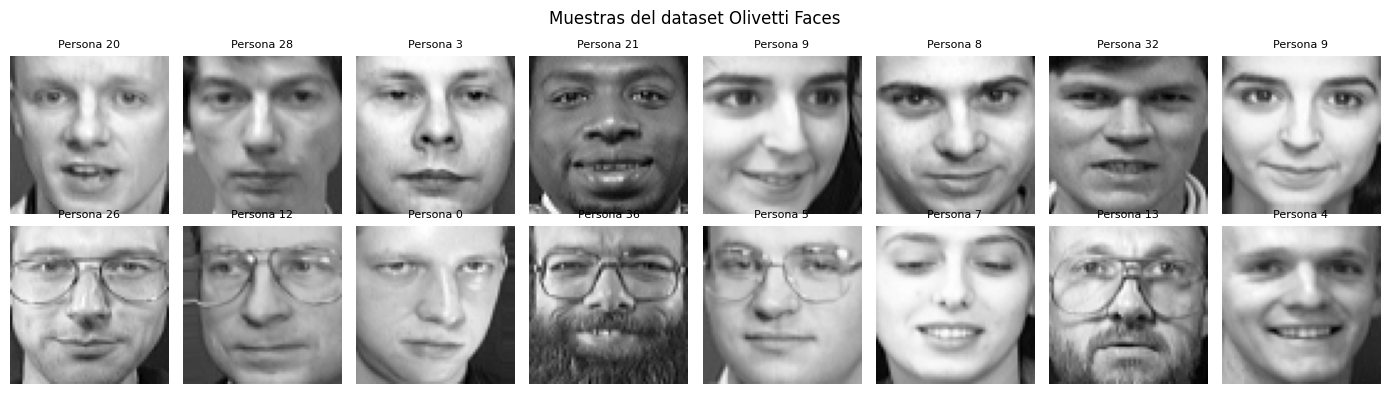

In [ ]:
# Mostrar algunas muestras del dataset
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Persona {y[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Muestras del dataset Olivetti Faces")
plt.tight_layout()
plt.show()

## 2. División en conjuntos de entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 300 muestras
Prueba: 100 muestras


## 3. Aplicación de PCA (Eigenfaces)
Cada imagen (4096 dimensiones) se proyecta sobre un subespacio de menor dimensión formado por
las componentes principales, llamadas **eigenfaces**. `whiten=True` normaliza la varianza de cada
componente, lo cual suele mejorar el desempeño del clasificador posterior.

In [ ]:
n_components = 100  # numero de eigenfaces a conservar

pca = PCA(n_components=n_components, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Dimension original: {X_train.shape[1]}")
print(f"Dimension reducida (PCA): {X_train_pca.shape[1]}")
print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Dimension original: 4096
Dimension reducida (PCA): 100
Varianza explicada acumulada: 94.37%


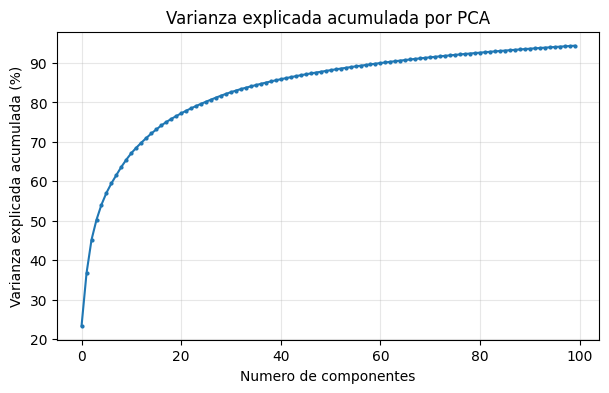

In [ ]:
# Curva de varianza explicada acumulada
plt.figure(figsize=(7,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o', markersize=2)
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza explicada acumulada (%)")
plt.title("Varianza explicada acumulada por PCA")
plt.grid(alpha=0.3)
plt.show()

## 4. Visualización del rostro promedio y las eigenfaces

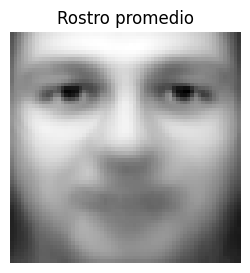

In [ ]:
mean_face = pca.mean_.reshape(64, 64)
plt.figure(figsize=(3,3))
plt.imshow(mean_face, cmap='gray')
plt.title("Rostro promedio")
plt.axis('off')
plt.show()

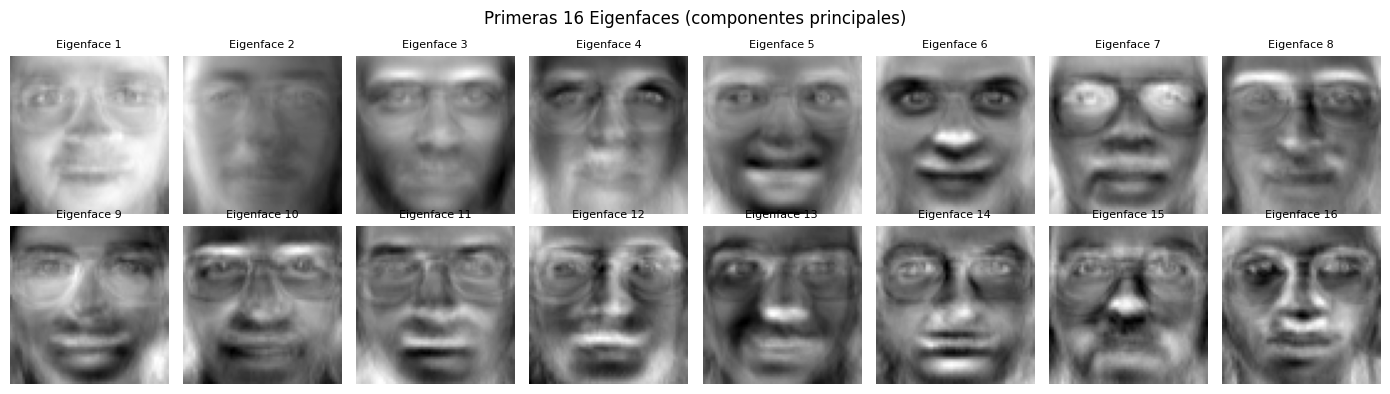

In [ ]:
eigenfaces = pca.components_.reshape((n_components, 64, 64))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f"Eigenface {i+1}", fontsize=8)
    ax.axis('off')
plt.suptitle("Primeras 16 Eigenfaces (componentes principales)")
plt.tight_layout()
plt.show()

## 5. Reconstrucción de rostros
Se reconstruye un rostro usando distinto número de eigenfaces para observar cómo mejora
la calidad de la reconstrucción conforme se incrementan las componentes.

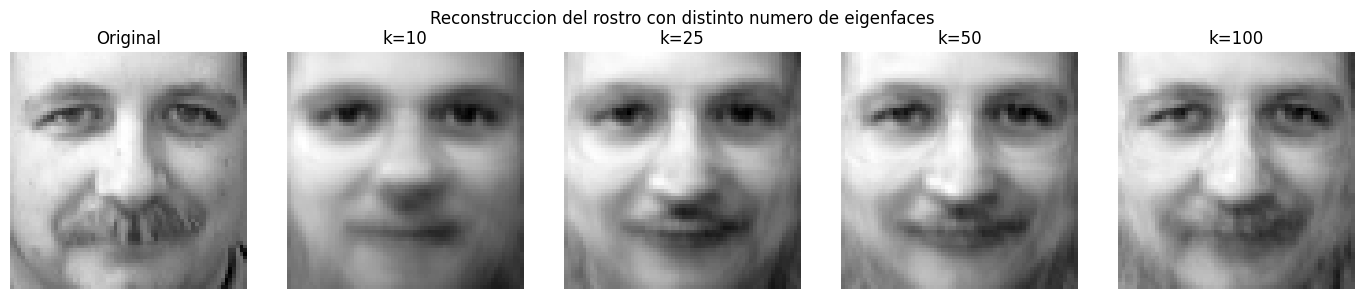

In [ ]:
idx = 0  # indice de la imagen de prueba a reconstruir
original = X_test[idx].reshape(64, 64)

componentes_prueba = [10, 25, 50, 100]
fig, axes = plt.subplots(1, len(componentes_prueba) + 1, figsize=(14, 3))

axes[0].imshow(original, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, k in enumerate(componentes_prueba):
    pca_k = PCA(n_components=k, whiten=True, random_state=42).fit(X_train)
    proj = pca_k.transform(X_test[idx:idx+1])
    recon = pca_k.inverse_transform(proj).reshape(64, 64)
    axes[i+1].imshow(recon, cmap='gray')
    axes[i+1].set_title(f"k={k}")
    axes[i+1].axis('off')

plt.suptitle("Reconstruccion del rostro con distinto numero de eigenfaces")
plt.tight_layout()
plt.show()

## 6. Entrenamiento de clasificadores
Se entrenan dos clasificadores clásicos (sin redes neuronales) sobre las proyecciones PCA:
- **SVM (kernel RBF)** con búsqueda de hiperparámetros
- **K-Nearest Neighbors (KNN)**

In [ ]:
param_grid = {
    "C": [1e3, 5e3, 1e4, 5e4],
    "gamma": [0.0001, 0.0005, 0.001, 0.005],
}
grid_svc = GridSearchCV(
    SVC(kernel="rbf", class_weight="balanced"), param_grid, cv=5, n_jobs=-1
)
grid_svc.fit(X_train_pca, y_train)

print("Mejores hiperparametros SVM:", grid_svc.best_params_)
best_svc = grid_svc.best_estimator_

Mejores hiperparametros SVM: {'C': 1000.0, 'gamma': 0.005}


In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)

KNeighborsClassifier(n_neighbors=1)

## 7. Evaluación de los modelos

In [ ]:
pred_svc = best_svc.predict(X_test_pca)
pred_knn = knn.predict(X_test_pca)

acc_svc = accuracy_score(y_test, pred_svc)
acc_knn = accuracy_score(y_test, pred_knn)

print(f"Accuracy SVM: {acc_svc*100:.2f}%")
print(f"Accuracy KNN (k=1): {acc_knn*100:.2f}%")

Accuracy SVM: 98.00%
Accuracy KNN (k=1): 92.00%


In [ ]:
print("Reporte de clasificacion - SVM\n")
print(classification_report(y_test, pred_svc, zero_division=0))

Reporte de clasificacion - SVM

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         3
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00      

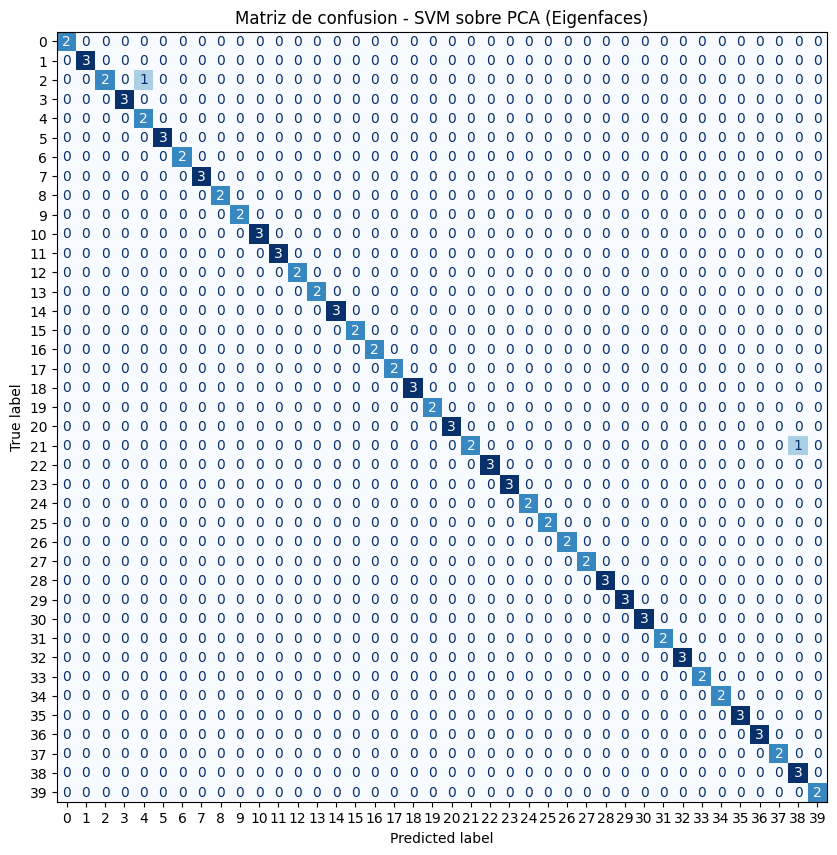

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
cm = confusion_matrix(y_test, pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Matriz de confusion - SVM sobre PCA (Eigenfaces)")
plt.show()

## 8. Predicciones de ejemplo (visual)

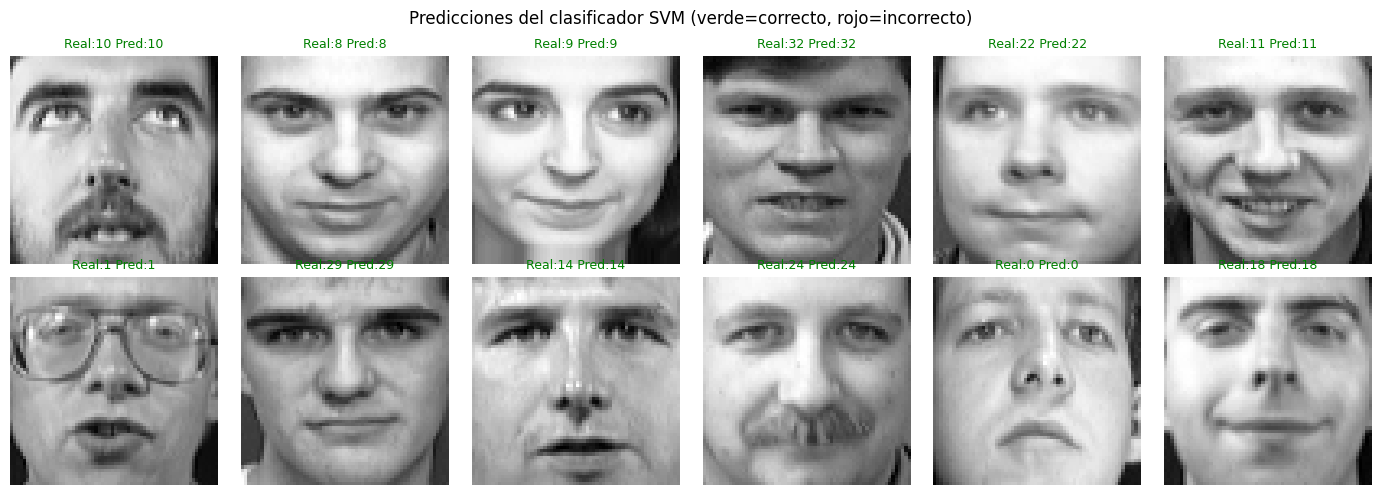

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
sample_idx = np.random.choice(len(X_test), 12, replace=False)

for ax, idx in zip(axes.flat, sample_idx):
    img = X_test[idx].reshape(64, 64)
    real = y_test[idx]
    pred = pred_svc[idx]
    ax.imshow(img, cmap='gray')
    color = 'green' if real == pred else 'red'
    ax.set_title(f"Real:{real} Pred:{pred}", fontsize=9, color=color)
    ax.axis('off')

plt.suptitle("Predicciones del clasificador SVM (verde=correcto, rojo=incorrecto)")
plt.tight_layout()
plt.show()

-------------

# **CASO 3: Sistema de recomendación de artículos con NMF**

---

Factorización No Negativa de Matrices (NMF) y Similitud de Coseno

**Enunciado:**

Supongan que forman parte del grupo de Machine Learning en un importante periódico en línea. Les han asignado la tarea de recomendar artículos similares al artículo que está leyendo actualmente un cliente. Es decir, dado un artículo, se debe encontrar artículos que tengan temas similares. Resuelvan el problema usando NMF y similitud de coseno o alguno similar.


## 1. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)


## 2. Carga del dataset: 20 Newsgroups

Quitamos encabezados, pies
de firma y texto citado (`remove=('headers','footers','quotes')`) porque son metadatos que no
aportan al tema del artículo y pueden filtrar información.


In [ ]:
categories = [
    'sci.space',
    'sci.med',
    'rec.sport.baseball',
    'rec.autos',
    'comp.graphics',
    'talk.politics.mideast',
    'soc.religion.christian',
    'misc.forsale',
]

newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42,
)

documents = newsgroups.data
labels = newsgroups.target
target_names = newsgroups.target_names

print(f"Numero de articulos: {len(documents)}")
print(f"Categorias: {target_names}")


Numero de articulos: 7846
Categorias: ['comp.graphics', 'misc.forsale', 'rec.autos', 'rec.sport.baseball', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.mideast']


In [ ]:
# Vista rapida de un articulo de ejemplo
idx_ejemplo = 0
print("Categoria real:", target_names[labels[idx_ejemplo]])
print("-" * 60)
print(documents[idx_ejemplo][:600])


Categoria real: rec.autos
------------------------------------------------------------
--

Are the any Opel GT's out there? I'm wondering if there are enough to
starting a mail list...

----------------------------------------------------------------------------
Matthew R. Singer                                    MIT Lincoln Laboratory
(617) 981-3771                                       244 Wood Street
singer@ll.mit.edu                                    Lexington, MA 02173


## 3. Filtrado de artículos muy cortos

Algunos mensajes del dataset quedan casi vacíos tras remover encabezados y citas. Un artículo con
muy pocas palabras no aporta señal temática confiable, asi que se van al tacho :)


In [ ]:
min_chars = 200
mask = np.array([len(doc) >= min_chars for doc in documents])

documents = [doc for doc, m in zip(documents, mask) if m]
labels = labels[mask]

print(f"Articulos despues del filtro: {len(documents)}")


Articulos despues del filtro: 6251


## 4. Representación vectorial: TF-IDF

NMF necesita una matriz **no negativa** como entrada. TF-IDF (Term Frequency - Inverse Document

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.6,
    min_df=5,
    max_features=5000,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print("Forma de la matriz TF-IDF (documentos x vocabulario):", tfidf_matrix.shape)


Forma de la matriz TF-IDF (documentos x vocabulario): (6251, 5000)


## 5. Descubrimiento de temas con NMF

Elegimos `n_components = 8`, coincidiendo con el número de categorías originales que seleccionamos,
para poder comparar visualmente los temas descubiertos por NMF contra las categorías reales del
dataset. En un caso real, este número se ajusta por prueba y error, o usando métricas
como la coherencia de tópicos.


In [ ]:
n_topics = 8

nmf_model = NMF(
    n_components=n_topics,
    init='nndsvd',
    random_state=42,
    max_iter=500,
)

W = nmf_model.fit_transform(tfidf_matrix)  # perfil tematico de cada articulo
H = nmf_model.components_                  # composicion de palabras por tema

print("Forma de W (documentos x temas):", W.shape)
print("Forma de H (temas x palabras):", H.shape)


Forma de W (documentos x temas): (6251, 8)
Forma de H (temas x palabras): (8, 5000)


In [ ]:
def mostrar_temas(H, feature_names, n_palabras=10):
    for i, tema in enumerate(H):
        top_indices = tema.argsort()[::-1][:n_palabras]
        palabras = feature_names[top_indices]
        print(f"Tema {i}: {', '.join(palabras)}")

mostrar_temas(H, feature_names, n_palabras=10)


Tema 0: god, jesus, christ, church, sin, bible, faith, christians, believe, christian
Tema 1: 00, sale, shipping, offer, drive, condition, 10, price, 50, new
Tema 2: geb, cadre, dsl, n3jxp, chastity, pitt, skepticism, surrender, shameful, intellect
Tema 3: armenian, armenians, turkish, genocide, armenia, turkey, people, turks, muslim, soviet
Tema 4: graphics, image, thanks, program, space, file, files, mail, information, ftp
Tema 5: car, cars, engine, new, dealer, miles, ford, oil, speed, good
Tema 6: don, think, just, like, year, good, time, know, people, game
Tema 7: israel, jews, israeli, arab, jewish, arabs, state, palestinian, peace, palestinians


## 6. Similitud entre artículos: similitud de coseno sobre el espacio de temas

Comparamos artículos con similitud de coseno en vez de distancia euclidiana porque
lo que importa es la proporción de temas que comparten (la dirección del vector), no la
magnitud absoluta (que depende del largo del artículo).



In [ ]:
similarity_matrix = cosine_similarity(W)
print("Forma de la matriz de similitud:", similarity_matrix.shape)


Forma de la matriz de similitud: (6251, 6251)


In [ ]:
def recomendar_articulos(indice_articulo, top_n=5):
    '''Devuelve los top_n articulos mas similares a documents[indice_articulo],
    usando la similitud de coseno sobre el perfil tematico obtenido con NMF.'''
    similitudes = similarity_matrix[indice_articulo]

    # ordenamos de mayor a menor similitud, excluyendo el propio articulo
    indices_ordenados = similitudes.argsort()[::-1]
    indices_ordenados = indices_ordenados[indices_ordenados != indice_articulo]
    top_indices = indices_ordenados[:top_n]

    resultados = pd.DataFrame({
        'indice': top_indices,
        'similitud': similitudes[top_indices],
        'categoria_real': [target_names[labels[i]] for i in top_indices],
        'extracto': [documents[i][:150].replace(chr(10), ' ') for i in top_indices],
    })
    return resultados


## 7. Demostración del sistema de recomendación

Un lector está viendo un artículo (`indice_articulo`) y el sistema le sugiere los siguientes `top_n`
artículos que probablemente le interesen.


In [ ]:
idx_consulta = 10
print("ARTICULO CONSULTADO")
print("Categoria real:", target_names[labels[idx_consulta]])
print(documents[idx_consulta][:400])
print()
print("ARTICULOS RECOMENDADOS")
recomendar_articulos(idx_consulta, top_n=5)


ARTICULO CONSULTADO
Categoria real: talk.politics.mideast
In a previous article, sadek@cbnewsg.cb.att.com (mohamed.s.sa 

Mohamed,

What has he got to say about the carnage and genocide in our own SUDAN?
The two scenarios must be viewed from the same perspective or don't you
think so? well, methinks. no flames intended!!!

oguocha





ARTICULOS RECOMENDADOS


,indice,similitud,categoria_real,extracto
0,913,0.998600,rec.sport.baseball,"Currently, he's all over. He played 2nd when..."
1,2022,0.997830,rec.sport.baseball,I doubt Henderson would clear waivers. And i...
2,1156,0.997753,sci.med,"I've heard of NO studies, but speculation: W..."
3,3036,0.997159,talk.politics.mideast,Accounts of Anti-Armenian Human Rights Violati...
4,5028,0.997023,talk.politics.mideast,[KAAN] Who the hell is this guy David Davidia...


In [ ]:
idx_consulta_2 = 250
print("ARTICULO CONSULTADO")
print("Categoria real:", target_names[labels[idx_consulta_2]])
print(documents[idx_consulta_2][:400])
print()
print("ARTICULOS RECOMENDADOS")
recomendar_articulos(idx_consulta_2, top_n=5)


ARTICULO CONSULTADO
Categoria real: talk.politics.mideast
 
[TC] Do you, as I do, agree that this (sort) of "peace process" is needed?
[TC] What about the particular points mentioned in the article? Is what
[TC] Israel is (supposedly) going to propose "good"? Does it go too far?
[TC] Not far enough?

[TC] If you don't agree that a "peace process" is needed, what is?

I personally think that a peace process is needed, since only through
negotiations will 

ARTICULOS RECOMENDADOS


,indice,similitud,categoria_real,extracto
0,3344,0.999908,talk.politics.mideast,I have no idea what this guy means but the ...
1,5850,0.999768,talk.politics.mideast,\tI have to say I think this is the first time...
2,515,0.999727,talk.politics.mideast,G-d has nothing to do with it. Some of the lan...
3,1027,0.999724,talk.politics.mideast,"What is this ""Gaza""? Are you purposely separa..."
4,400,0.999650,talk.politics.mideast,"Well, you should have noted that I was cheer..."


In [ ]:
idx_consulta_3 = 900
print("ARTICULO CONSULTADO")
print("Categoria real:", target_names[labels[idx_consulta_3]])
print(documents[idx_consulta_3][:400])
print()
print("ARTICULOS RECOMENDADOS")
recomendar_articulos(idx_consulta_3, top_n=5)


ARTICULO CONSULTADO
Categoria real: talk.politics.mideast



"Muslim" in ex-Yugoslavia was a *nation* not a religion.  In fact, not
all Muslims in B-H are followers of Islam.  Therefore, there do (did?)
exist in ex-Yugoslavia "Christian Muslims."  Tito defined the Muslim 
nation constitutionally, adding Muslims to Serbs, Croats, and Slovenes,
the three founding nations which entered into a voluntary union at the
end of WWI.  In addition, Tito added two o

ARTICULOS RECOMENDADOS


,indice,similitud,categoria_real,extracto
0,297,0.999200,talk.politics.mideast,You are somewhat close to truth. But you s...
1,2983,0.995605,talk.politics.mideast,"Because, the x-Soviet Armenian government go..."
2,190,0.990515,talk.politics.mideast,Bosnian Muslims are citizens od Bosnia-Herzeg...
3,1723,0.989792,talk.politics.mideast,"Muslims already have, they accepted the Vanc..."
4,3001,0.987624,talk.politics.mideast,"Tell me, 'kmagnacca', were you high on 'Arr..."


En los tres ejemplos anteriores se espera observar que la gran mayoría de los artículos
recomendados pertenecen a la **misma categoría real** que el artículo consultado, aun cuando el
sistema nunca tuvo acceso a esa etiqueta durante el entrenamiento. Esto es evidencia directa de que
el perfil temático aprendido por NMF captura correctamente el contenido del artículo.


## 8. Evaluación cuantitativa del sistema

Medimos la calidad de las
recomendaciones sobre todo el corpus con: **precisión de categoría en el
top-N**.


In [ ]:
def precision_en_top_n(top_n=5, n_muestra=400, semilla=42):
    rng = np.random.default_rng(semilla)
    total_docs = len(documents)
    indices_muestra = rng.choice(total_docs, size=min(n_muestra, total_docs), replace=False)

    aciertos_nmf = []
    aciertos_azar = []

    for idx in indices_muestra:
        categoria_real = labels[idx]

        # sistema basado en NMF + coseno
        similitudes = similarity_matrix[idx]
        indices_ordenados = similitudes.argsort()[::-1]
        indices_ordenados = indices_ordenados[indices_ordenados != idx][:top_n]
        aciertos = np.mean(labels[indices_ordenados] == categoria_real)
        aciertos_nmf.append(aciertos)

        # linea base aleatoria
        candidatos = [i for i in range(total_docs) if i != idx]
        seleccion_azar = rng.choice(candidatos, size=top_n, replace=False)
        aciertos_random = np.mean(labels[seleccion_azar] == categoria_real)
        aciertos_azar.append(aciertos_random)

    return np.mean(aciertos_nmf), np.mean(aciertos_azar)

precision_nmf, precision_azar = precision_en_top_n(top_n=5, n_muestra=400)
print(f"Precision@5 sistema NMF + coseno: {precision_nmf:.3f}")
print(f"Precision@5 recomendacion aleatoria: {precision_azar:.3f}")


Precision@5 sistema NMF + coseno: 0.669
Precision@5 recomendacion aleatoria: 0.127


In [ ]:
resultados_por_n = []
for n in [1, 3, 5, 10]:
    p_nmf, p_azar = precision_en_top_n(top_n=n, n_muestra=400)
    resultados_por_n.append({'top_n': n, 'precision_nmf': p_nmf, 'precision_azar': p_azar})

df_resultados = pd.DataFrame(resultados_por_n)
df_resultados


,top_n,precision_nmf,precision_azar
0,1,0.6375,0.12750
1,3,0.6625,0.14000
2,5,0.6685,0.12700
3,10,0.6610,0.13075


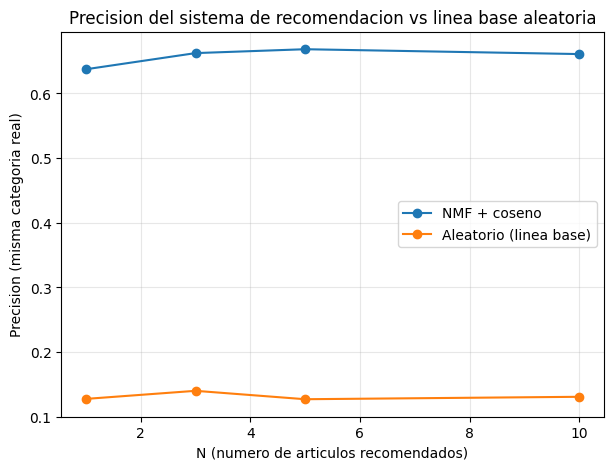

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(df_resultados['top_n'], df_resultados['precision_nmf'], marker='o', label='NMF + coseno')
plt.plot(df_resultados['top_n'], df_resultados['precision_azar'], marker='o', label='Aleatorio (linea base)')
plt.xlabel('N (numero de articulos recomendados)')
plt.ylabel('Precision (misma categoria real)')
plt.title('Precision del sistema de recomendacion vs linea base aleatoria')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. Visualización: perfil temático promedio por categoría real

Como verificación adicional, promediamos el perfil temático (`W`) de todos los artículos de cada
categoría real.


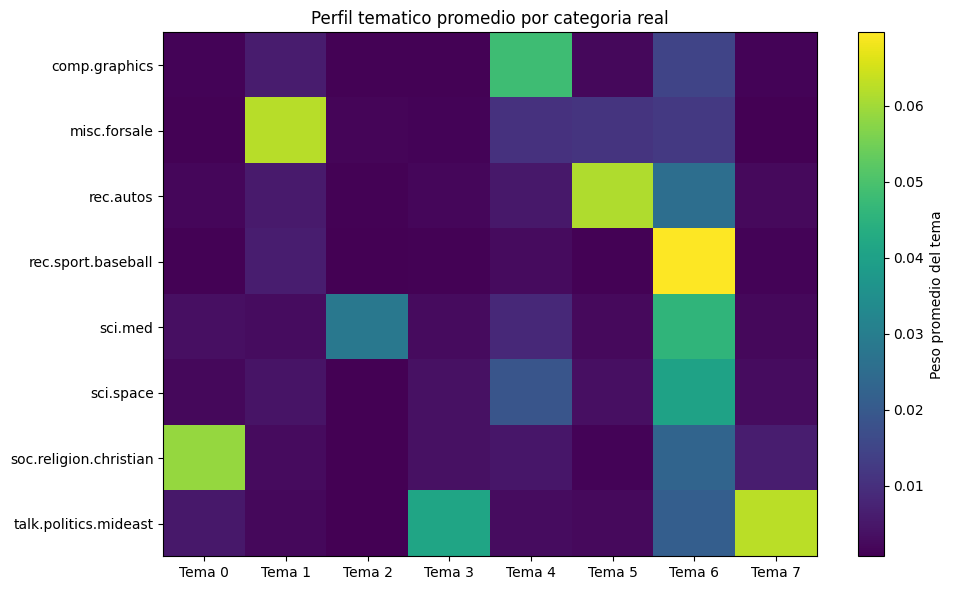

In [ ]:
df_w = pd.DataFrame(W, columns=[f"Tema {i}" for i in range(n_topics)])
df_w['categoria'] = [target_names[l] for l in labels]

perfil_promedio = df_w.groupby('categoria').mean()

plt.figure(figsize=(10, 6))
plt.imshow(perfil_promedio.values, aspect='auto', cmap='viridis')
plt.colorbar(label='Peso promedio del tema')
plt.xticks(range(n_topics), [f"Tema {i}" for i in range(n_topics)])
plt.yticks(range(len(perfil_promedio)), perfil_promedio.index)
plt.title('Perfil tematico promedio por categoria real')
plt.tight_layout()
plt.show()
